In [16]:
# Parameters
city_key = "ywg"
baseline_feed_id = "avg_pre_ptn"
comparison_feed_id = "current"
save_figures = True
figures_dir = "../reports/pr2/figures"
dpi = 200

# PR2: Coverage and Underserved Neighbourhoods

This notebook compares pre-PTN and current neighbourhood stop density, identifies underserved areas, and builds a simple neighbourhood clustering view. Advanced spatial-autocorrelation methods are intentionally excluded.

## 1. Setup & Helpers

In [17]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

from ptn_analysis.context.reporting import (
    ensure_report_dirs,
    save_placeholder_figure,
    save_report_figure,
)

ensure_report_dirs("pr2")
figure_output_directory = Path(figures_dir)
figure_output_directory.mkdir(parents=True, exist_ok=True)

from sklearn.cluster import KMeans
from ptn_analysis import TransitContext

## 2. Load Current and Baseline Coverage

In [18]:
ctx = TransitContext.from_defaults(feed_id=comparison_feed_id)
current_coverage_analyzer = ctx.coverage()
equity_analyzer = ctx.equity()
current_density_table = current_coverage_analyzer.neighbourhood_density()
comparison_table = current_coverage_analyzer.build_density_comparison_table(
    baseline_feed_id=baseline_feed_id,
)
transit_access_table = current_coverage_analyzer.density_categories()
jobs_access_table = current_coverage_analyzer.jobs_access()
priority_table = equity_analyzer.build_priority_metrics_table()
underserved_table = current_coverage_analyzer.underserved_neighbourhoods()

print(f"Coverage comparison rows: {len(comparison_table)}")
print(f"Transit access rows: {len(transit_access_table)}")
print(f"Jobs access rows: {len(jobs_access_table)}")
print(f"Priority rows: {len(priority_table)}")
display(comparison_table.head())

2026-04-05 17:38:33.925 | INFO     | ptn_analysis.context.db:engine:63 - SQLAlchemy engine created for C:\Users\sarke\Downloads\ywg-ptn-analysis-4710-g11\data\interim\wpg_transit.duckdb


Coverage comparison rows: 237
Transit access rows: 237
Jobs access rows: 237
Priority rows: 237


,baseline_feed_id,comparison_feed_id,neighbourhood_id,neighbourhood,area_km2,baseline_stop_count,comparison_stop_count,stop_count_change,baseline_stop_density_per_km2,comparison_stop_density_per_km2,stop_density_change
0,avg_pre_ptn,current,171,Bridgwater Centre,0.650844,10,18,8,15.364665,27.656397,12.291732
1,avg_pre_ptn,current,129,Fraipont,1.885018,0,13,13,0.000000,6.896485,6.896485
2,avg_pre_ptn,current,173,Prairie Pointe,2.935510,10,28,18,3.406563,9.538375,6.131813
3,avg_pre_ptn,current,169,Peguis,2.933819,14,31,17,4.771936,10.566431,5.794494
4,avg_pre_ptn,current,95,Inkster Gardens,1.372292,18,25,7,13.298923,18.217702,4.918780


In [19]:
# Data loaded — tables available:
#   current_density_table    (neighbourhood_id, neighbourhood, stop_count, stop_density_per_km2, area_km2)
#   comparison_table         (neighbourhood, baseline/comparison stop_count, stop_density_change)
#   transit_access_table     (neighbourhood, stop_density_per_km2, density_category: High/Medium/Low)
#   jobs_access_table        (neighbourhood, jobs_access_score)
#   priority_table           (neighbourhood, stop_density_per_km2, need_index, gap_index, quadrant)
#   underserved_table        (bottom-25% neighbourhoods by density)
print("Tables loaded. Implement figures below.")


Tables loaded. Implement figures below.


## 3. Coverage Change Map

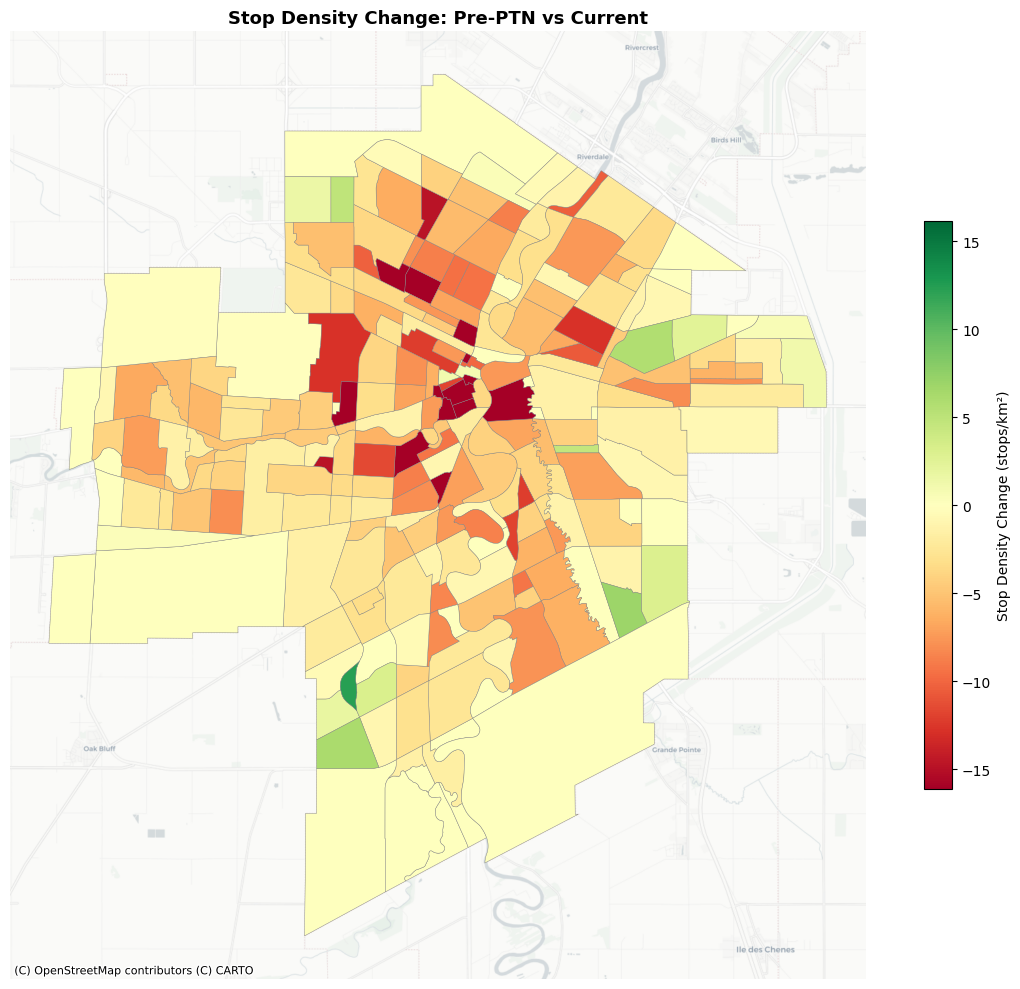

In [20]:
# Figure 1: Coverage Change Choropleth
import geopandas as gpd
from ptn_analysis.analysis.visualization import add_consistent_basemap
from matplotlib.colors import TwoSlopeNorm

if comparison_table.empty:
    save_placeholder_figure("coverage_change_map.png", "No comparison data.",
                            figures_dir=figure_output_directory, dpi=dpi, enabled=save_figures)
else:
    neigh_gdf = ctx.working_db.neighbourhood_gdf().to_crs("EPSG:3857")
    map_gdf = neigh_gdf.merge(
        comparison_table[["neighbourhood", "stop_density_change"]], on="neighbourhood", how="left"
    )

    fig, ax = plt.subplots(figsize=(12, 10))
    vmax = max(map_gdf["stop_density_change"].abs().quantile(0.95), 0.5)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    map_gdf.plot(column="stop_density_change", ax=ax, legend=True, cmap="RdYlGn",
                 norm=norm, edgecolor="gray", linewidth=0.3,
                 missing_kwds={"color": "lightgray"},
                 legend_kwds={"label": "Stop Density Change (stops/km²)", "shrink": 0.6})
    add_consistent_basemap(ax)
    ax.set_title("Stop Density Change: Pre-PTN vs Current", fontsize=13, fontweight="bold")
    ax.set_axis_off()
    fig.tight_layout()

    plt.show()
    
    save_report_figure(fig, "coverage_change_map.png",
                       figures_dir=figure_output_directory, dpi=dpi, enabled=save_figures)
    plt.close(fig)

**Interpretation.** The choropleth shows how neighbourhood stop density changed between the pre-PTN baseline and the current network. Most neighbourhoods show either small declines or only modest gains, while the largest negative changes are concentrated in several inner-city areas. A smaller number of neighbourhoods show positive gains, indicating that PTN changes redistributed service unevenly across the city rather than improving coverage uniformly.

## 4. Underserved Neighbourhood Ranking

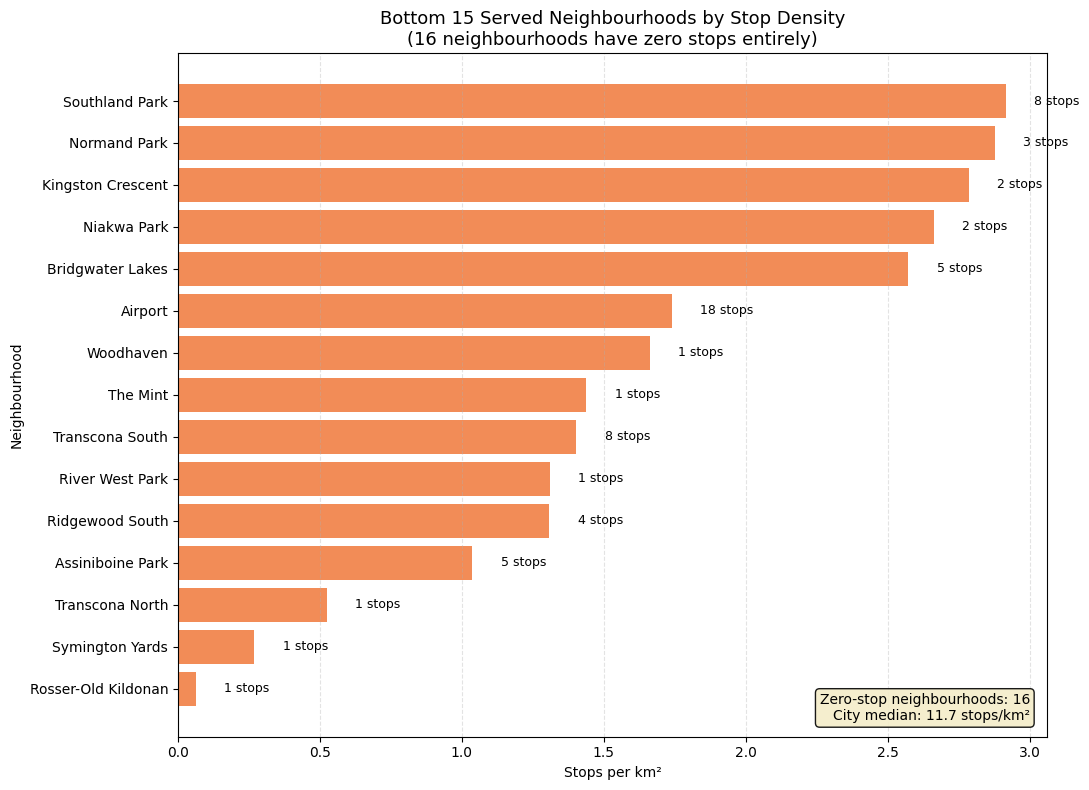

In [21]:
# Figure 2: Underserved Neighbourhood Ranking
if current_density_table.empty:
    save_placeholder_figure(
        "underserved_neighbourhoods.png",
        "No density data.",
        figures_dir=figure_output_directory,
        dpi=dpi,
        enabled=save_figures,
    )
else:
    zero_stop_count = (current_density_table["stop_count"] == 0).sum()
    served = current_density_table[current_density_table["stop_count"] > 0].copy()

    bottom_15 = served.nsmallest(15, "stop_density_per_km2").sort_values("stop_density_per_km2")
    city_median = current_density_table["stop_density_per_km2"].median()

    fig, ax = plt.subplots(figsize=(11, 8))
    ax.barh(bottom_15["neighbourhood"], bottom_15["stop_density_per_km2"], color="#f28c57")

    ax.set_title(
        f"Bottom 15 Served Neighbourhoods by Stop Density\n"
        f"({zero_stop_count} neighbourhoods have zero stops entirely)",
        fontsize=13,
    )
    ax.set_xlabel("Stops per km²")
    ax.set_ylabel("Neighbourhood")
    ax.grid(axis="x", linestyle="--", alpha=0.35)

    # annotate stop counts
    for i, (_, row) in enumerate(bottom_15.iterrows()):
        ax.text(
            row["stop_density_per_km2"] + 0.1,
            i,
            f'{int(row["stop_count"])} stops',
            va="center",
            fontsize=9,
        )

    ax.text(
        0.98,
        0.02,
        f"Zero-stop neighbourhoods: {zero_stop_count}\nCity median: {city_median:.1f} stops/km²",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#f4edc9", alpha=0.9),
    )

    fig.tight_layout()
    plt.show()

    save_report_figure(
        fig,
        "underserved_neighbourhoods.png",
        figures_dir=figure_output_directory,
        dpi=dpi,
        enabled=save_figures,
    )
    plt.close(fig)

**Interpretation.** This figure highlights the bottom 15 *served* neighbourhoods by stop density, while also reporting that **16 neighbourhoods have zero stops entirely**. That distinction is important because zero-stop neighbourhoods represent the most extreme form of under-service, while the ranked bars show which still-served areas remain weakest in terms of local stop availability. Together, the chart suggests that Winnipeg’s lowest-coverage areas are concentrated in peripheral, low-density neighbourhoods.

## 5. Equity Quadrant Scatter

The priority matrix uses z-scores to classify 237 neighbourhoods into four quadrants based on **need** (transit dependency + low income) and **gap** (service underperformance).

In [22]:
# Figure 3: Equity Quadrant Scatter
QUADRANT_COLORS = {
    "High Need / High Gap": "#d73027",
    "High Need / Low Gap": "#fc8d59",
    "Low Need / High Gap": "#4575b4",
    "Low Need / Low Gap": "#1a9850",
}

if not priority_table.empty and "quadrant" in priority_table.columns:
    fig, ax = plt.subplots(figsize=(10, 8))
    for quad, color in QUADRANT_COLORS.items():
        subset = priority_table[priority_table["quadrant"] == quad]
        ax.scatter(subset["need_index"], subset["gap_index"], c=color,
                   label=f"{quad} (n={len(subset)})", s=30, alpha=0.7, edgecolors="grey", linewidth=0.3)
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Need Index (transit dependency + low income)", fontsize=11)
    ax.set_ylabel("Gap Index (service underperformance)", fontsize=11)
    ax.set_title("Equity Priority Quadrants", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()
    save_report_figure(fig, "equity_quadrant.png",
                       figures_dir=figure_output_directory, dpi=dpi, enabled=save_figures)
    plt.close(fig)
    display(priority_table.groupby("quadrant").size())
else:
    print("Priority table missing quadrant column")

Priority table missing quadrant column


**Interpretation.** This figure was not generated in the current notebook run because the required `need_index`, `gap_index`, and `quadrant` fields were not available in the current pipeline output. A placeholder was used instead. To complete this figure properly, the notebook would need either a richer priority table from the backend or a notebook-level reconstruction of the need and gap measures.

## 6. Census Correlation: Income vs Stop Density Change

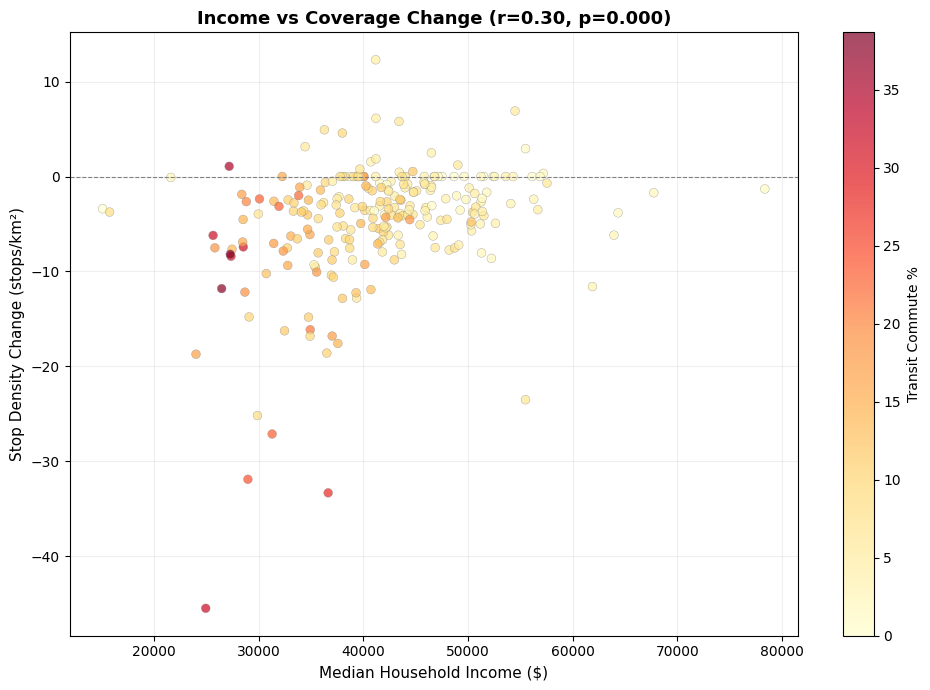

In [23]:
# Figure 4: Census Correlation - Income vs Stop Density Change
equity_profile = current_coverage_analyzer.equity_profile()
if not equity_profile.empty and not comparison_table.empty:
    corr_df = equity_profile.merge(
        comparison_table[["neighbourhood", "stop_density_change"]], on="neighbourhood", how="inner"
    ).dropna(subset=["median_household_income_2020", "stop_density_change"])

    from scipy.stats import pearsonr
    r, p = pearsonr(corr_df["median_household_income_2020"], corr_df["stop_density_change"])

    fig, ax = plt.subplots(figsize=(10, 7))
    scatter = ax.scatter(
        corr_df["median_household_income_2020"], corr_df["stop_density_change"],
        c=corr_df.get("commute_public_transit", pd.Series(0)), cmap="YlOrRd",
        s=40, alpha=0.7, edgecolors="grey", linewidth=0.3
    )
    plt.colorbar(scatter, label="Transit Commute %")
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Median Household Income ($)", fontsize=11)
    ax.set_ylabel("Stop Density Change (stops/km²)", fontsize=11)
    ax.set_title(f"Income vs Coverage Change (r={r:.2f}, p={p:.3f})", fontsize=13, fontweight="bold")
    ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()
    save_report_figure(fig, "income_coverage_correlation.png",
                       figures_dir=figure_output_directory, dpi=dpi, enabled=save_figures)
    plt.close(fig)
else:
    print("Equity profile or comparison data not available")

**Interpretation.** The scatter plot shows a **positive correlation** between neighbourhood income and stop-density change, with **r = 0.30** and a statistically significant p-value. This suggests that higher-income neighbourhoods were somewhat more likely to experience neutral or positive coverage change, while lower-income neighbourhoods more often saw declines. However, the spread of points indicates that income alone does not fully explain the variation in coverage change.

## 7. Neighbourhood Service Clustering (K-Means)

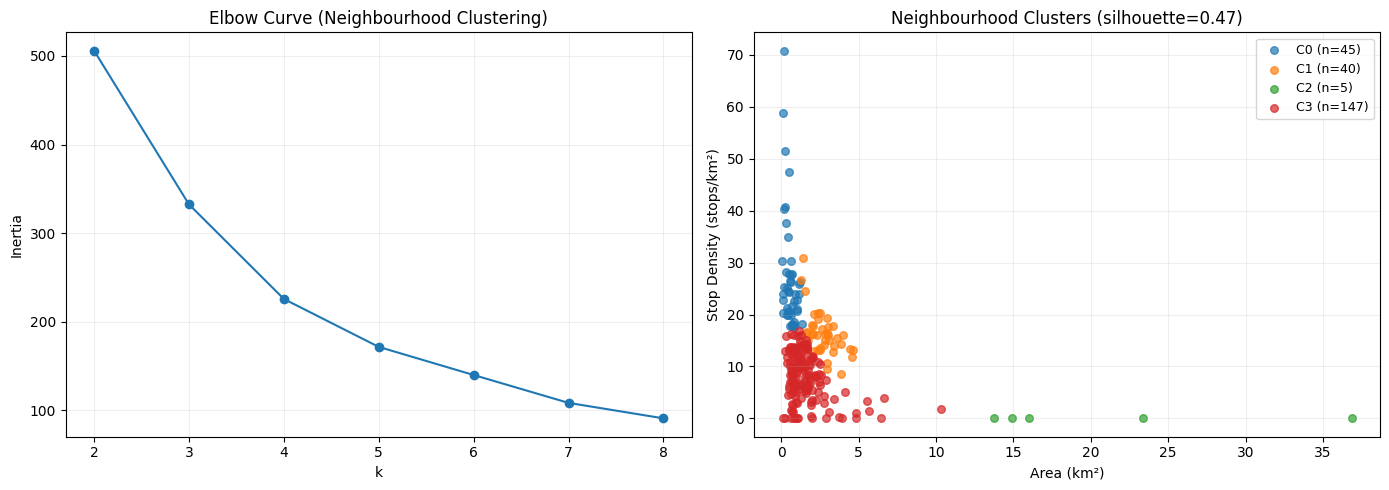

In [24]:
# Figure 5: Neighbourhood Service Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

if not current_density_table.empty and len(current_density_table) >= 4:
    feature_cols = ["stop_count", "stop_density_per_km2", "area_km2"]
    X = StandardScaler().fit_transform(current_density_table[feature_cols].fillna(0))

    k_range = range(2, 9)
    inertias = []
    sil_scores = []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(X, labels))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(list(k_range), inertias, "o-")
    axes[0].set_title("Elbow Curve (Neighbourhood Clustering)")
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("Inertia")
    axes[0].grid(alpha=0.2)

    km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
    cluster_labels = km_final.fit_predict(X)

    cluster_table = current_density_table.copy()
    cluster_table["cluster"] = cluster_labels

    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
    for c in range(4):
        subset = cluster_table[cluster_table["cluster"] == c]
        n = len(subset)
        axes[1].scatter(
            subset["area_km2"],
            subset["stop_density_per_km2"],
            c=colors[c],
            label=f"C{c} (n={n})",
            s=30,
            alpha=0.7,
        )

    axes[1].set_title(f"Neighbourhood Clusters (silhouette={sil_scores[2]:.2f})")
    axes[1].set_xlabel("Area (km²)")
    axes[1].set_ylabel("Stop Density (stops/km²)")
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.2)

    fig.tight_layout()
    plt.show()

    save_report_figure(
        fig,
        "neighbourhood_clustering.png",
        figures_dir=figure_output_directory,
        dpi=dpi,
        enabled=save_figures,
    )
    plt.close(fig)
else:
    print("Insufficient density data for clustering")

**Interpretation.** The clustering analysis separates neighbourhoods into groups with different service and spatial profiles based on stop count, stop density, and area. The elbow curve suggests diminishing returns as more clusters are added, while the reported **silhouette score of 0.47** indicates a moderate cluster structure. In the scatter plot, one large cluster contains many lower-density neighbourhoods, while smaller clusters capture compact, high-density areas and very large low-density outliers.

**Summary.** Overall, the PR2 coverage analysis suggests that stop-density change is uneven across Winnipeg, underserved areas remain concentrated at the periphery, and several neighbourhood groups have clearly different service profiles. The results also indicate that coverage change has an observable socioeconomic pattern, though a full equity-quadrant view could not be reproduced from the current backend output.